# Import data

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

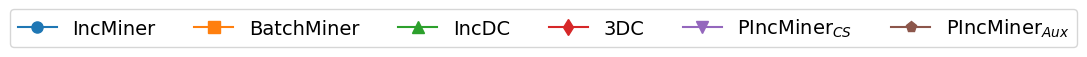

In [5]:
# Global style map: label -> {color, marker, markersize} for consistent naming and styling across plots

MARKER_SIZE = 8
FONT_SIZE = 14
plt.rc('font', size=FONT_SIZE)
plt.rc('axes', labelsize=FONT_SIZE, titlesize=FONT_SIZE)
plt.rc('xtick', labelsize=FONT_SIZE)
plt.rc('ytick', labelsize=FONT_SIZE)
plt.rc('legend', fontsize=FONT_SIZE)

STYLE_MAP = {
    'IncMiner':   {'color': 'C0', 'marker': 'o', 'markersize': MARKER_SIZE},
    'BatchMiner': {'color': 'C1', 'marker': 's', 'markersize': MARKER_SIZE},
    'IncDC':      {'color': 'C2', 'marker': '^', 'markersize': MARKER_SIZE},
    '3DC':        {'color': 'C3', 'marker': 'd', 'markersize': MARKER_SIZE},
    r'PIncMiner$_{CS}$':  {'color': 'C4', 'marker': 'v', 'markersize': MARKER_SIZE},
    r'PIncMiner$_{Aux}$': {'color': 'C5', 'marker': 'p', 'markersize': MARKER_SIZE},
}

# Wide figure with legend only (shared across all figures)
from matplotlib.lines import Line2D
fig_legend = plt.figure(figsize=(6, 0.6))
handles = [Line2D([], [], **{**STYLE_MAP[k], 'linestyle': '-'}, label=k) for k in STYLE_MAP]
fig_legend.legend(handles=handles, ncol=6, loc='center', frameon=True)
plt.axis('off')
plt.tight_layout()
import os
os.makedirs('plots', exist_ok=True)
fig_legend.savefig('plots/legend.pdf', bbox_inches='tight')
plt.show()

In [6]:
# Read all sheets into a dictionary of DataFrames
inc_dc_dfs = pd.read_excel('IncDC-0310.xlsx', sheet_name=None)
three_dc_dfs = pd.read_excel('3DC实验结果-0313.xlsx', sheet_name=None)

# Print the names of the sheets
print('IncDC:', inc_dc_dfs.keys())
print('3DC:', three_dc_dfs.keys())

IncDC: dict_keys(['adult varying |ΔD+|', 'airports varying |ΔD+|', 'adult varying |D|', 'airports varying |D|'])
3DC: dict_keys(['adult varying |ΔD+|', 'airports varying |ΔD+|', 'adult varying |ΔD-|', 'airports varying |ΔD-|', 'adult varying |D|', 'airports varying |D|'])


In [7]:
df_adult = pd.read_csv('vs_incdc/experiment_results_adult.csv')

In [138]:
df_adult

,experiment_type,dataset,origin_size,column_number,scale,scale_size,support,confidence,inc_type,inc_ratio,...,inc_expansion_time_s,inc_aff_calculate_time_s,counter_sketch_error_bound,counter_sketch_failure_probability,batch_time_s,batch_rule_number,batch_memory_mb,rule_lhs_max_size,inc_model_retrain_time_s,inc_decision_tree_time_s
0,SCALE,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,0.2,6512,2,1,add,0.01,...,0.000007,0.098289,4.036699e+05,1.051271,0.146611,38,24.498886,20,0.000143,0
1,SCALE,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,0.4,13024,2,1,add,0.01,...,0.000008,0.172167,1.615159e+06,1.051271,0.237297,38,62.477219,20,0.000115,0
2,SCALE,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,0.6,19536,2,1,add,0.01,...,0.000008,0.283884,3.632044e+06,1.051271,0.380548,38,50.840271,20,0.000100,0
3,SCALE,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,0.8,26048,2,1,add,0.01,...,0.000010,0.325291,6.458266e+06,1.051271,0.487807,38,40.410255,20,0.000101,0
4,SCALE,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,2,1,add,0.01,...,0.000007,0.247146,1.008818e+07,1.051271,0.565291,38,144.628784,20,0.000536,0
5,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,2,1,add,0.01,...,0.000005,0.180408,1.008818e+07,1.051271,0.460722,38,92.878799,20,0.000380,0
6,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,2,1,add,0.05,...,0.000014,1.076503,1.008890e+07,1.051271,0.545102,38,165.701637,20,0.000527,0
7,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,2,1,add,0.15,...,0.000015,3.380454,1.008983e+07,1.051271,0.629009,38,91.767960,20,0.000072,0
8,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,2,1,add,0.20,...,0.000015,4.861246,1.009251e+07,1.051271,0.641417,38,142.455505,20,0.000078,0
9,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,2,1,add,0.30,...,0.000017,6.630350,1.008968e+07,1.051271,0.719883,38,279.037178,20,0.000740,0


In [139]:
# Separate by experiment_type: SCALE vs ADD
df_adult_scale = df_adult[df_adult['experiment_type'] == 'SCALE'].copy()
df_adult_add = df_adult[df_adult['experiment_type'] == 'ADD'].copy()

In [140]:
# ADD experiments only
df_adult_add

,experiment_type,dataset,origin_size,column_number,scale,scale_size,support,confidence,inc_type,inc_ratio,...,inc_expansion_time_s,inc_aff_calculate_time_s,counter_sketch_error_bound,counter_sketch_failure_probability,batch_time_s,batch_rule_number,batch_memory_mb,rule_lhs_max_size,inc_model_retrain_time_s,inc_decision_tree_time_s
5,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,2,1,add,0.01,...,0.000005,0.180408,1.008818e+07,1.051271,0.460722,38,92.878799,20,0.000380,0
6,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,2,1,add,0.05,...,0.000014,1.076503,1.008890e+07,1.051271,0.545102,38,165.701637,20,0.000527,0
7,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,2,1,add,0.15,...,0.000015,3.380454,1.008983e+07,1.051271,0.629009,38,91.767960,20,0.000072,0
8,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,2,1,add,0.20,...,0.000015,4.861246,1.009251e+07,1.051271,0.641417,38,142.455505,20,0.000078,0
9,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,2,1,add,0.30,...,0.000017,6.630350,1.008968e+07,1.051271,0.719883,38,279.037178,20,0.000740,0


# Exp-1 Compare with DCs

## Vary $|\Delta D_+|$

In [141]:
inc_dc = inc_dc_dfs['adult varying |ΔD+|']
inc_dc_3dc = three_dc_dfs['adult varying |ΔD+|']

In [142]:
inc_dc

,数据集,base行数,增量模式,增量比例,增量行数,DC数量,耗时（ms）,备注
0,adult,22792,add,0.01,326,2991,3319,NaN
1,adult,22792,add,0.05,1629,2981,6470,NaN
2,adult,22792,add,0.15,4884,2959,23708,NaN
3,adult,22792,add,0.20,6512,2919,34620,NaN
4,adult,22792,add,0.30,9769,2956,71932,NaN


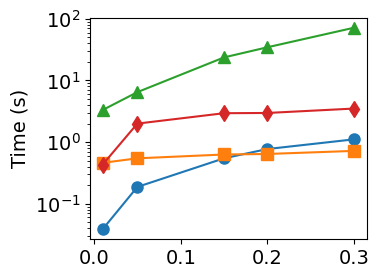

Adult DC ADD — IncMiner over BatchMiner: avg 3.50x, max 11.95x
Adult DC ADD — IncMiner over 3DC: avg 6.86x, max 11.21x
Adult DC ADD — IncMiner over IncDC: avg 54.78x, max 86.12x


,inc_ratio,IncMiner,BatchMiner,IncDC_s,3DC_s
row,,,,,
0,0.01,0.038539,0.460722,3.319,0.432
1,0.05,0.187059,0.545102,6.470,1.996
2,0.15,0.545622,0.629009,23.708,2.944
3,0.20,0.771849,0.641417,34.620,2.971
4,0.30,1.108589,0.719883,71.932,3.504


In [278]:
# Extract the three columns: inc_ratio (x), inc_time_s and batch_time_s (mining times)
plot_df = df_adult_add[['inc_ratio', 'inc_time_s', 'batch_time_s']].sort_values('inc_ratio')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(plot_df['inc_ratio'], plot_df['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(plot_df['inc_ratio'], plot_df['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(inc_dc['增量比例'], inc_dc['耗时（ms）'] / 1000, label='IncDC', **STYLE_MAP['IncDC'])
ax.plot(inc_dc_3dc['增量比例'], inc_dc_3dc['耗时（ms）'] / 1000, label='3DC', **STYLE_MAP['3DC'])
# ax.set_xlabel('Increment ratio ($|\Delta D_+| / |D|$)')
ax.set_ylabel('Time (s)')
ax.set_yscale('log')
# ax.set_title('Adult (ADD): mining time vs increment ratio')
fig.savefig('plots/adult_dc_add.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

# Table with row numbers: inc_ratio and times (s) for each method
tbl = plot_df.rename(columns={'inc_time_s': 'IncMiner', 'batch_time_s': 'BatchMiner'}).copy()
tbl = tbl.merge(inc_dc[['增量比例', '耗时（ms）']].rename(columns={'增量比例': 'inc_ratio', '耗时（ms）': 'IncDC_ms'}), on='inc_ratio', how='outer')
tbl = tbl.merge(inc_dc_3dc[['增量比例', '耗时（ms）']].rename(columns={'增量比例': 'inc_ratio', '耗时（ms）': '3DC_ms'}), on='inc_ratio', how='outer')
tbl['IncDC_s'] = tbl['IncDC_ms'] / 1000
tbl['3DC_s'] = tbl['3DC_ms'] / 1000
tbl = tbl.sort_values('inc_ratio').drop(columns=['IncDC_ms', '3DC_ms'])
tbl.index.name = 'row'
# Speedup (IncMiner over BatchMiner, 3DC, IncDC)
inc = tbl['IncMiner']
for name, other in [('BatchMiner', tbl['BatchMiner']), ('3DC', tbl['3DC_s']), ('IncDC', tbl['IncDC_s'])]:
    valid = (inc > 0) & (other.notna()) & (other > 0)
    if valid.any(): s = (other / inc)[valid]; print(f'Adult DC ADD — IncMiner over {name}: avg {s.mean():.2f}x, max {s.max():.2f}x')
display(tbl)

## Other experiment results: Airports

In [144]:
# Read airports CSV and split by experiment_type (SCALE vs ADD); keep ADD only
df_airports = pd.read_csv('vs_incdc/experiment_results_airports.csv')
df_airports_add = df_airports[df_airports['experiment_type'] == 'ADD'].copy()

# Extract inc_ratio and times for IncMiner and BatchMiner (same as adult)
plot_df_airports = df_airports_add[['inc_ratio', 'inc_time_s', 'batch_time_s']].sort_values('inc_ratio')
plot_df_airports

,inc_ratio,inc_time_s,batch_time_s
5,0.01,0.200302,2.903009
6,0.05,1.098257,3.098383
7,0.15,2.901849,3.433985
8,0.20,3.780447,3.675836
9,0.30,5.234088,3.972272


## Speedup summary

In [26]:
# PIncMinerCS (no_count_sketch) vs IncMiner: how much slower is PIncMinerCS? (Exp1 has no no_count_sketch; use Exp2 where both exist)
exp2_v3 = ['inc_vs_batch_v3/experiment_results_dblp_agg.csv', 'inc_vs_batch_v3/experiment_results_hospital_ml.csv', 'inc_vs_batch_v3/experiment_results_ncvoter_ml.csv', 'inc_vs_batch_v3/experiment_results_adult_ml.csv', 'inc_vs_batch_v3/experiment_results_inspection_ml.csv']
exp2_cs = ['inc_vs_batch_no_count_sketch/experiment_results_dblp_agg.csv', 'inc_vs_batch_no_count_sketch/experiment_results_hospital_ml.csv', 'inc_vs_batch_no_count_sketch/experiment_results_ncvoter_ml.csv', 'inc_vs_batch_no_count_sketch/experiment_results_adult_ml.csv', 'inc_vs_batch_no_count_sketch/experiment_results_inspection_ml.csv']
ratios = []
for f_v3, f_cs in zip(exp2_v3, exp2_cs):
    df_v3 = pd.read_csv(f_v3)
    df_cs = pd.read_csv(f_cs)
    for exp_type in ['ADD', 'DELETE']:
        v3 = df_v3[df_v3['experiment_type'] == exp_type][['inc_ratio', 'inc_time_s']].dropna()
        cs = df_cs[df_cs['experiment_type'] == exp_type][['inc_ratio', 'inc_time_s']].rename(columns={'inc_time_s': 'inc_cs_time_s'})
        m = v3.merge(cs, on='inc_ratio', how='inner')
        m = m[(m['inc_time_s'] > 0) & (m['inc_cs_time_s'] > 0)]
        if len(m):
            ratios.extend((m['inc_cs_time_s'] / m['inc_time_s']).tolist())
if ratios:
    print(f'PIncMinerCS vs IncMiner (Exp2, ADD+DELETE): avg {sum(ratios)/len(ratios):.2f}x slower, max {max(ratios):.2f}x slower')
else:
    print('No matched rows.')

PIncMinerCS vs IncMiner (Exp2, ADD+DELETE): avg 2.26x slower, max 4.62x slower


In [ ]:
# Count batch rules mined from each dataset (inc_vs_batch_v3; one representative row per dataset)
import re
files = [
    'inc_vs_batch_v3/experiment_results_dblp_agg.csv',
    'inc_vs_batch_v3/experiment_results_hospital_ml.csv',
    'inc_vs_batch_v3/experiment_results_ncvoter_ml.csv',
    'inc_vs_batch_v3/experiment_results_adult_ml.csv',
    'inc_vs_batch_v3/experiment_results_inspection_ml.csv',
]
print('Dataset              | batch_rule_number')
print('---------------------|------------------')
for path in files:
    name = re.sub(r'experiment_results_|\.csv', '', path.split('/')[-1])
    df = pd.read_csv(path)
    if 'batch_rule_number' not in df.columns:
        print(f'{name:20} | (no column)')
        continue
    # Use first ADD row with inc_ratio=0.01 if present, else first row
    add_small = df[(df['experiment_type'] == 'ADD') & (df['inc_ratio'] == 0.01)]
    row = add_small.iloc[0] if len(add_small) else df.iloc[0]
    n = int(row['batch_rule_number'])
    print(f'{name:20} | {n}')

In [24]:
# Exp1 and Exp2: IncMiner over BatchMiner — average and maximum speedup
# Exp1: vs_incdc (adult, airports); Exp2: inc_vs_batch_v3 (hospital, ncvoter, dblp_agg, adult_ml, inspection_ml)
exp1_files = ['vs_incdc/experiment_results_adult.csv', 'vs_incdc/experiment_results_airports.csv']
exp2_files = [
    'inc_vs_batch_v3/experiment_results_dblp_agg.csv',
    'inc_vs_batch_v3/experiment_results_hospital_ml.csv',
    'inc_vs_batch_v3/experiment_results_ncvoter_ml.csv',
    'inc_vs_batch_v3/experiment_results_adult_ml.csv',
    'inc_vs_batch_v3/experiment_results_inspection_ml.csv',
]
all_files = exp1_files + exp2_files
dfs = []
for f in all_files:
    try:
        df = pd.read_csv(f)
        df = df[['inc_time_s', 'batch_time_s']].dropna()
        df = df[(df['inc_time_s'] > 0) & (df['batch_time_s'] > 0)]
        dfs.append(df)
    except Exception as e:
        pass
if dfs:
    combined = pd.concat(dfs, ignore_index=True)
    speedup = combined['batch_time_s'] / combined['inc_time_s']
    print('Exp1 & Exp2 — IncMiner over BatchMiner:')
    print(f'  Average speedup: {speedup.mean():.2f}x')
    print(f'  Maximum speedup: {speedup.max():.2f}x')
else:
    print('No data found for Exp1/Exp2.')

Exp1 & Exp2 — IncMiner over BatchMiner:
  Average speedup: 3.96x
  Maximum speedup: 107.85x


In [193]:
# Exp1: minimal recall (vs_incdc — adult, airports)
exp1_files = ['vs_incdc/experiment_results_adult.csv', 'vs_incdc/experiment_results_airports.csv']
recalls = []
for f in exp1_files:
    try:
        df = pd.read_csv(f)
        if 'inc_recall' in df.columns:
            r = df['inc_recall'].dropna()
            recalls.extend(r.tolist())
    except Exception:
        pass
if recalls:
    print(f'Exp1 — minimal recall: {min(recalls):.4f}')
else:
    print('No inc_recall found in Exp1 data.')

Exp1 — minimal recall: 0.8889


In [25]:
# PIncMinerNS (no_sample) vs IncMiner: how much slower is PIncMinerNS? (Exp1 has no no_sample; use Exp2 where both exist)
exp2_v3 = ['inc_vs_batch_v3/experiment_results_dblp_agg.csv', 'inc_vs_batch_v3/experiment_results_hospital_ml.csv', 'inc_vs_batch_v3/experiment_results_ncvoter_ml.csv', 'inc_vs_batch_v3/experiment_results_adult_ml.csv', 'inc_vs_batch_v3/experiment_results_inspection_ml.csv']
exp2_ns = ['inc_vs_batch_no_sample/experiment_results_dblp_agg.csv', 'inc_vs_batch_no_sample/experiment_results_hospital_ml.csv', 'inc_vs_batch_no_sample/experiment_results_ncvoter_ml.csv', 'inc_vs_batch_no_sample/experiment_results_adult_ml.csv', 'inc_vs_batch_no_sample/experiment_results_inspection_ml.csv']
ratios = []
for f_v3, f_ns in zip(exp2_v3, exp2_ns):
    df_v3 = pd.read_csv(f_v3)
    df_ns = pd.read_csv(f_ns)
    for exp_type in ['ADD', 'DELETE']:
        v3 = df_v3[df_v3['experiment_type'] == exp_type][['inc_ratio', 'inc_time_s']].dropna()
        ns = df_ns[df_ns['experiment_type'] == exp_type][['inc_ratio', 'inc_time_s']].rename(columns={'inc_time_s': 'inc_ns_time_s'})
        m = v3.merge(ns, on='inc_ratio', how='inner')
        m = m[(m['inc_time_s'] > 0) & (m['inc_ns_time_s'] > 0)]
        if len(m):
            ratios.extend((m['inc_ns_time_s'] / m['inc_time_s']).tolist())
if ratios:
    print(f'PIncMinerNS vs IncMiner (Exp2, ADD+DELETE): avg {sum(ratios)/len(ratios):.2f}x slower, max {max(ratios):.2f}x slower')
else:
    print('No matched rows.')

PIncMinerNS vs IncMiner (Exp2, ADD+DELETE): avg 2.21x slower, max 4.49x slower


In [301]:
# Cross-dataset comparison (Exp2): DBLP_agg vs NCVoter — IncMiner runtime: how much slower on DBLP than on NCVoter (ADD and DELETE separate)
dblp = pd.read_csv('inc_vs_batch_v3/experiment_results_dblp_agg.csv')
ncvoter = pd.read_csv('inc_vs_batch_v3/experiment_results_ncvoter_ml.csv')

for exp_type, label in [('ADD', 'ADD'), ('DELETE', 'DELETE')]:
    dblp_sub = dblp[dblp['experiment_type'] == exp_type]['inc_time_s'].dropna()
    ncv_sub = ncvoter[ncvoter['experiment_type'] == exp_type]['inc_time_s'].dropna()
    dblp_sub = dblp_sub[dblp_sub > 0]
    ncv_sub = ncv_sub[ncv_sub > 0]
    if len(dblp_sub) and len(ncv_sub):
        t_dblp = dblp_sub.mean()
        t_ncv = ncv_sub.mean()
        ratio = t_dblp / t_ncv
        print(f'{label}: IncMiner avg time DBLP_agg {t_dblp:.2f}s, NCVoter {t_ncv:.2f}s')
        print(f'  → IncMiner on DBLP_agg is {ratio:.2f}x slower than on NCVoter')

ADD: IncMiner avg time DBLP_agg 182.55s, NCVoter 56.94s
  → IncMiner on DBLP_agg is 3.21x slower than on NCVoter
DELETE: IncMiner avg time DBLP_agg 181.70s, NCVoter 51.33s
  → IncMiner on DBLP_agg is 3.54x slower than on NCVoter


In [ ]:
# Comparison with DCs: IncMiner over BatchMiner, 3DC, IncDC — average and maximum speedup
# Uses adult ADD and airports ADD with aligned IncDC and 3DC times from Excel

def build_dc_merged(df_add, inc_dc_df, three_dc_df):
    plot_df = df_add[['inc_ratio', 'inc_time_s', 'batch_time_s']].rename(
        columns={'inc_time_s': 'IncMiner', 'batch_time_s': 'BatchMiner'})
    tbl = plot_df.merge(
        inc_dc_df[['增量比例', '耗时（ms）']].rename(columns={'增量比例': 'inc_ratio', '耗时（ms）': 'IncDC_ms'}),
        on='inc_ratio', how='outer')
    tbl = tbl.merge(
        three_dc_df[['增量比例', '耗时（ms）']].rename(columns={'增量比例': 'inc_ratio', '耗时（ms）': '3DC_ms'}),
        on='inc_ratio', how='outer')
    tbl['IncDC_s'] = tbl['IncDC_ms'] / 1000
    tbl['3DC_s'] = tbl['3DC_ms'] / 1000
    return tbl[['inc_ratio', 'IncMiner', 'BatchMiner', 'IncDC_s', '3DC_s']].dropna(subset=['IncMiner'])

df_adult_add = df_adult[df_adult['experiment_type'] == 'ADD'].copy()
df_airports_add = df_airports[df_airports['experiment_type'] == 'ADD'].copy()
inc_dc = inc_dc_dfs['adult varying |ΔD+|']
inc_dc_3dc = three_dc_dfs['adult varying |ΔD+|']
inc_dc_airports = inc_dc_dfs['airports varying |ΔD+|']
inc_dc_3dc_airports = three_dc_dfs['airports varying |ΔD+|']

tbl_adult = build_dc_merged(df_adult_add, inc_dc, inc_dc_3dc)
tbl_airports = build_dc_merged(df_airports_add, inc_dc_airports, inc_dc_3dc_airports)
tbl_dc = pd.concat([tbl_adult, tbl_airports], ignore_index=True)

inc = tbl_dc['IncMiner']
for name, other in [('BatchMiner', tbl_dc['BatchMiner']), ('3DC', tbl_dc['3DC_s']), ('IncDC', tbl_dc['IncDC_s'])]:
    valid = (inc > 0) & (other > 0)
    if valid.any():
        s = (other / inc)[valid]
        print(f'IncMiner over {name}: avg {s.mean():.2f}x, max {s.max():.2f}x')
    else:
        print(f'IncMiner over {name}: no valid pairs')

IncMiner over BatchMiner: avg 3.77x, max 14.49x
IncMiner over 3DC: avg 4.11x, max 11.21x
IncMiner over IncDC: avg 56.28x, max 86.12x


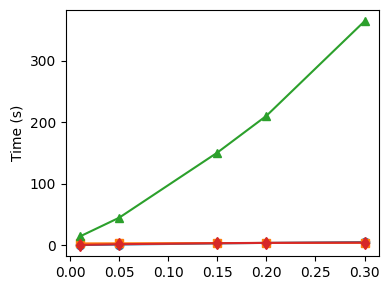

In [174]:
# IncDC DataFrame: airports varying |ΔD+|
inc_dc_airports = inc_dc_dfs['airports varying |ΔD+|']
inc_dc_3dc_airports = three_dc_dfs['airports varying |ΔD+|']

# Same plot as adult: IncMiner, BatchMiner, IncDC, 3DC (time 耗时 ms -> s); log scale
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(plot_df_airports['inc_ratio'], plot_df_airports['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(plot_df_airports['inc_ratio'], plot_df_airports['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(inc_dc_airports['增量比例'], inc_dc_airports['耗时（ms）'] / 1000, label='IncDC', **STYLE_MAP['IncDC'])
ax.plot(inc_dc_3dc_airports['增量比例'], inc_dc_3dc_airports['耗时（ms）'] / 1000, label='3DC', **STYLE_MAP['3DC'])
# ax.set_xlabel('Increment ratio ($|\\Delta D_+| / |D|$)')
ax.set_ylabel('Time (s)')
fig.savefig('plots/airports_dc_add.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
# Speedup (IncMiner over BatchMiner, 3DC, IncDC)
tbl_ap = plot_df_airports.rename(columns={'inc_time_s': 'IncMiner', 'batch_time_s': 'BatchMiner'}).merge(
    inc_dc_airports[['增量比例', '耗时（ms）']].rename(columns={'增量比例': 'inc_ratio', '耗时（ms）': 'IncDC_ms'}), on='inc_ratio', how='outer').merge(
    inc_dc_3dc_airports[['增量比例', '耗时（ms）']].rename(columns={'增量比例': 'inc_ratio', '耗时（ms）': '3DC_ms'}), on='inc_ratio', how='outer')
tbl_ap['IncDC_s'] = tbl_ap['IncDC_ms'] / 1000; tbl_ap['3DC_s'] = tbl_ap['3DC_ms'] / 1000
inc_ap = tbl_ap['IncMiner']
for name, other in [('BatchMiner', tbl_ap['BatchMiner']), ('3DC', tbl_ap['3DC_s']), ('IncDC', tbl_ap['IncDC_s'])]:
    valid = (inc_ap > 0) & (other.notna()) & (other > 0)
    if valid.any(): s = (other / inc_ap)[valid]; print(f'Airports DC ADD — IncMiner over {name}: avg {s.mean():.2f}x, max {s.max():.2f}x')


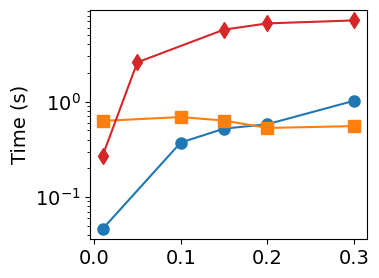

Adult DC DEL — IncMiner over BatchMiner: avg 3.62x, max 13.60x
Adult DC DEL — IncMiner over 3DC: avg 8.81x, max 11.44x


In [ ]:
# Deletion case: Adult (IncMiner, BatchMiner, 3DC)

# Filter DELETE experiments (inc_type == 'delete')
df_adult_delete = df_adult[df_adult['inc_type'] == 'delete'].copy()
df_airports_delete = df_airports[df_airports['inc_type'] == 'delete'].copy()

# Sort by increment ratio
plot_adult_del = df_adult_delete[['inc_ratio', 'inc_time_s', 'batch_time_s']].sort_values('inc_ratio')
plot_airports_del = df_airports_delete[['inc_ratio', 'inc_time_s', 'batch_time_s']].sort_values('inc_ratio')

# 3DC deletion data come from the |ΔD-| sheets in the same Excel file
inc_dc_3dc_adult_del = three_dc_dfs['adult varying |ΔD-|']
inc_dc_3dc_airports_del = three_dc_dfs['airports varying |ΔD-|']

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(plot_adult_del['inc_ratio'], plot_adult_del['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(plot_adult_del['inc_ratio'], plot_adult_del['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(inc_dc_3dc_adult_del['增量比例'], inc_dc_3dc_adult_del['耗时（ms）'] / 1000, label='3DC', **STYLE_MAP['3DC'])
ax.set_ylabel('Time (s)')
ax.set_yscale('log')


fig.savefig('plots/adult_dc_del.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
# Speedup (IncMiner over BatchMiner, 3DC)
tbl_ad = plot_adult_del.rename(columns={'inc_time_s': 'IncMiner', 'batch_time_s': 'BatchMiner'}).merge(
    inc_dc_3dc_adult_del[['增量比例', '耗时（ms）']].rename(columns={'增量比例': 'inc_ratio', '耗时（ms）': '3DC_ms'}), on='inc_ratio', how='outer')
tbl_ad['3DC_s'] = tbl_ad['3DC_ms'] / 1000
inc_ad = tbl_ad['IncMiner']
for name, other in [('BatchMiner', tbl_ad['BatchMiner']), ('3DC', tbl_ad['3DC_s'])]:
    valid = (inc_ad > 0) & (other.notna()) & (other > 0)
    if valid.any(): s = (other / inc_ad)[valid]; print(f'Adult DC DEL — IncMiner over {name}: avg {s.mean():.2f}x, max {s.max():.2f}x')


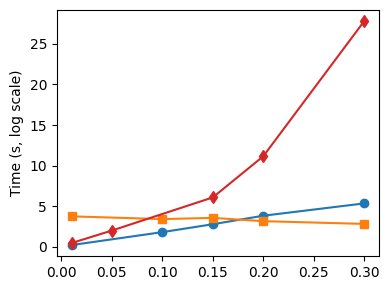

In [176]:
# Deletion case: Airports (IncMiner, BatchMiner, 3DC)

# Assumes df_airports_delete, plot_airports_del, and inc_dc_3dc_airports_del
# have been defined in the previous cell.

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(plot_airports_del['inc_ratio'], plot_airports_del['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(plot_airports_del['inc_ratio'], plot_airports_del['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(inc_dc_3dc_airports_del['增量比例'], inc_dc_3dc_airports_del['耗时（ms）'] / 1000, label='3DC', **STYLE_MAP['3DC'])
ax.set_ylabel('Time (s, log scale)')

plt.tight_layout()
plt.show()
# Speedup (IncMiner over BatchMiner, 3DC)
tbl_ap_del = plot_airports_del.rename(columns={'inc_time_s': 'IncMiner', 'batch_time_s': 'BatchMiner'}).merge(
    inc_dc_3dc_airports_del[['增量比例', '耗时（ms）']].rename(columns={'增量比例': 'inc_ratio', '耗时（ms）': '3DC_ms'}), on='inc_ratio', how='outer')
tbl_ap_del['3DC_s'] = tbl_ap_del['3DC_ms'] / 1000
inc_ap_d = tbl_ap_del['IncMiner']
for name, other in [('BatchMiner', tbl_ap_del['BatchMiner']), ('3DC', tbl_ap_del['3DC_s'])]:
    valid = (inc_ap_d > 0) & (other.notna()) & (other > 0)
    if valid.any(): s = (other / inc_ap_d)[valid]; print(f'Airports DC DEL — IncMiner over {name}: avg {s.mean():.2f}x, max {s.max():.2f}x')


## Rule count comparison: IncMiner vs IncDC (aligned by dataset and inc_ratio)

In [150]:
# Align on same dataset and inc_ratio; compare IncMiner rule count vs IncDC (DC数量).
# Expect: IncMiner >= IncDC (rules mined at least as many as DCs).

def compare_rules(inc_add_df, inc_dc_df, dataset_name):
    """inc_add_df: ADD rows with inc_ratio, inc_rule_number, batch_rule_number. inc_dc_df: 增量比例, DC数量."""
    inc = inc_add_df[['inc_ratio', 'inc_rule_number', 'batch_rule_number']].sort_values('inc_ratio').rename(
        columns={'inc_rule_number': 'IncMiner', 'batch_rule_number': 'BatchMiner'})
    dc = inc_dc_df[['增量比例', 'DC数量']].rename(columns={'增量比例': 'inc_ratio', 'DC数量': 'IncDC'})
    # align by inc_ratio (float)
    m = inc.merge(dc, on='inc_ratio', how='inner')
    m.insert(0, 'dataset', dataset_name)
    m['IncMiner >= IncDC'] = m['IncMiner'] >= m['IncDC']
    return m

adult_cmp = compare_rules(df_adult_add, inc_dc, 'adult')
airports_cmp = compare_rules(df_airports_add, inc_dc_airports, 'airports')
rule_comparison = pd.concat([adult_cmp, airports_cmp], ignore_index=True)
print('IncMiner >= IncDC for all rows:', rule_comparison['IncMiner >= IncDC'].all())
rule_comparison

IncMiner >= IncDC for all rows: False


,dataset,inc_ratio,IncMiner,BatchMiner,IncDC,IncMiner >= IncDC
0,adult,0.01,38,38,2991,False
1,adult,0.05,38,38,2981,False
2,adult,0.15,38,38,2959,False
3,adult,0.20,38,38,2919,False
4,adult,0.30,38,38,2956,False
5,airports,0.01,36,36,2596,False
6,airports,0.05,36,36,2657,False
7,airports,0.15,36,36,2644,False
8,airports,0.20,36,36,2621,False
9,airports,0.30,36,32,2957,False


# Exp1 

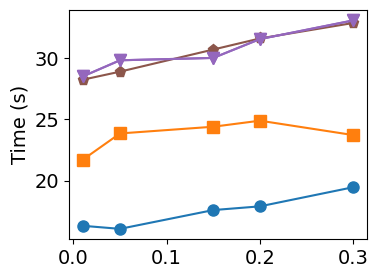

Hospital ADD — IncMiner over BatchMiner: avg 1.36x, max 1.49x


In [320]:
# ADD case: Hospital vs Ncvoter (IncMiner vs BatchMiner)

import pandas as pd
import matplotlib.pyplot as plt

# Load ML experiment results for Hospital and Ncvoter
hospital_ml = pd.read_csv('inc_vs_batch_v3/experiment_results_hospital_ml.csv')
ncvoter_ml = pd.read_csv('inc_vs_batch_v3/experiment_results_ncvoter_ml.csv')

# Keep only ADD (insertion) experiments
hospital_add = hospital_ml[hospital_ml['experiment_type'] == 'ADD'].copy()
ncvoter_add = ncvoter_ml[ncvoter_ml['experiment_type'] == 'ADD'].copy()

# Sort by increment ratio
hospital_add = hospital_add.sort_values('inc_ratio')
ncvoter_add = ncvoter_add.sort_values('inc_ratio')
# IncMinerNS baseline from inc_vs_batch_no_sample
hospital_ns = pd.read_csv('inc_vs_batch_no_sample/experiment_results_hospital_ml.csv')
hospital_ns_add = hospital_ns[hospital_ns['experiment_type']=='ADD'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
hospital_add = hospital_add.merge(hospital_ns_add, on='inc_ratio', how='left')


# IncMinerCS baseline from inc_vs_batch_no_count_sketch
hospital_cs = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_hospital_ml.csv')
hospital_cs_add = hospital_cs[hospital_cs['experiment_type']=='ADD'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
hospital_add = hospital_add.merge(hospital_cs_add, on='inc_ratio', how='left')

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(hospital_add['inc_ratio'], hospital_add['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(hospital_add['inc_ratio'], hospital_add['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(hospital_add['inc_ratio'], hospital_add['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(hospital_add['inc_ratio'], hospital_add['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
# ax.set_xlabel('Increment ratio ($|\Delta D_+| / |D|$)')
ax.set_ylabel('Time (s)')
# ax.set_title('Hospital (ADD): mining time vs increment ratio')
# ax.set_yscale('log')

fig.savefig('plots/hospital_add.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (hospital_add['inc_time_s'] > 0) & (hospital_add['batch_time_s'].notna()) & (hospital_add['batch_time_s'] > 0)
if valid.any(): s = hospital_add.loc[valid, 'batch_time_s'] / hospital_add.loc[valid, 'inc_time_s']; print(f'Hospital ADD — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


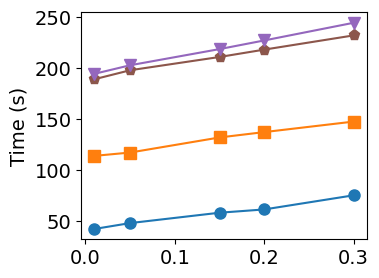

Ncvoter ADD — IncMiner over BatchMiner: avg 2.33x, max 2.70x


In [321]:
# ADD case: Ncvoter only (IncMiner vs BatchMiner)

# IncMinerNS from no_sample (ncvoter_add already defined in previous cell)
ncvoter_ns = pd.read_csv('inc_vs_batch_no_sample/experiment_results_ncvoter_ml.csv')
ncvoter_ns_add = ncvoter_ns[ncvoter_ns['experiment_type']=='ADD'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
ncvoter_add = ncvoter_add.merge(ncvoter_ns_add, on='inc_ratio', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
ncvoter_cs = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_ncvoter_ml.csv')
ncvoter_cs_add = ncvoter_cs[ncvoter_cs['experiment_type']=='ADD'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
ncvoter_add = ncvoter_add.merge(ncvoter_cs_add, on='inc_ratio', how='left')

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(ncvoter_add['inc_ratio'], ncvoter_add['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(ncvoter_add['inc_ratio'], ncvoter_add['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(ncvoter_add['inc_ratio'], ncvoter_add['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(ncvoter_add['inc_ratio'], ncvoter_add['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
# ax.set_xlabel('Increment ratio ($|\Delta D_+| / |D|$)')
ax.set_ylabel('Time (s)')
# ax.set_title('Ncvoter (ADD): mining time vs increment ratio')
# ax.set_yscale('log')

fig.savefig('plots/ncvoter_add.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (ncvoter_add['inc_time_s'] > 0) & (ncvoter_add['batch_time_s'].notna()) & (ncvoter_add['batch_time_s'] > 0)
if valid.any(): s = ncvoter_add.loc[valid, 'batch_time_s'] / ncvoter_add.loc[valid, 'inc_time_s']; print(f'Ncvoter ADD — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


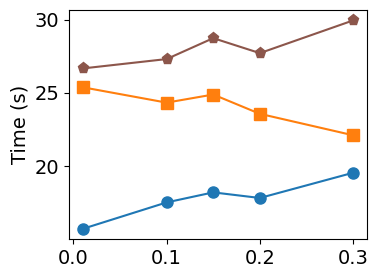

Hospital DELETE — IncMiner over BatchMiner: avg 1.36x, max 1.61x


In [9]:
# DELETE case: Hospital (IncMiner vs BatchMiner) — inc_vs_batch_v3 + IncMinerNS from no_sample

hospital_ml_del = pd.read_csv('inc_vs_batch_v3/experiment_results_hospital_ml.csv')
ncvoter_ml_del = pd.read_csv('inc_vs_batch_v3/experiment_results_ncvoter_ml.csv')

hospital_delete = hospital_ml_del[hospital_ml_del['experiment_type'] == 'DELETE'].copy()
ncvoter_delete = ncvoter_ml_del[ncvoter_ml_del['experiment_type'] == 'DELETE'].copy()

hospital_delete = hospital_delete.sort_values('inc_ratio')
ncvoter_delete = ncvoter_delete.sort_values('inc_ratio')
hospital_ns_del = pd.read_csv('inc_vs_batch_no_sample/experiment_results_hospital_ml.csv')
hospital_ns_del = hospital_ns_del[hospital_ns_del['experiment_type']=='DELETE'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
hospital_delete = hospital_delete.merge(hospital_ns_del, on='inc_ratio', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
hospital_cs_del = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_hospital_ml.csv')
hospital_cs_del = hospital_cs_del[hospital_cs_del['experiment_type']=='DELETE'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
hospital_delete = hospital_delete.merge(hospital_cs_del, on='inc_ratio', how='left')

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(hospital_delete['inc_ratio'], hospital_delete['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(hospital_delete['inc_ratio'], hospital_delete['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(hospital_delete['inc_ratio'], hospital_delete['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(hospital_delete['inc_ratio'], hospital_delete['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
# ax.set_xlabel('Increment ratio ($|\Delta D_-| / |D|$)')
ax.set_ylabel('Time (s)')
# ax.set_title('Hospital (DELETE): mining time vs increment ratio')
# ax.set_yscale('log')

fig.savefig('plots/hospital_delete.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (hospital_delete['inc_time_s'] > 0) & (hospital_delete['batch_time_s'].notna()) & (hospital_delete['batch_time_s'] > 0)
if valid.any(): s = hospital_delete.loc[valid, 'batch_time_s'] / hospital_delete.loc[valid, 'inc_time_s']; print(f'Hospital DELETE — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


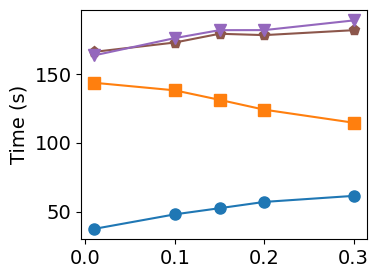

Ncvoter DELETE — IncMiner over BatchMiner: avg 2.65x, max 3.83x


In [10]:
# DELETE case: Ncvoter (IncMiner vs BatchMiner)

ncvoter_ns_del = pd.read_csv('inc_vs_batch_no_sample/experiment_results_ncvoter_ml.csv')
ncvoter_ns_del = ncvoter_ns_del[ncvoter_ns_del['experiment_type']=='DELETE'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
ncvoter_delete = ncvoter_delete.merge(ncvoter_ns_del, on='inc_ratio', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
ncvoter_cs_del = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_ncvoter_ml.csv')
ncvoter_cs_del = ncvoter_cs_del[ncvoter_cs_del['experiment_type']=='DELETE'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s': 'inc_cs_time_s'})
ncvoter_delete = ncvoter_delete.merge(ncvoter_cs_del, on='inc_ratio', how='left')

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(ncvoter_delete['inc_ratio'], ncvoter_delete['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(ncvoter_delete['inc_ratio'], ncvoter_delete['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(ncvoter_delete['inc_ratio'], ncvoter_delete['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(
    ncvoter_delete['inc_ratio'],
    ncvoter_delete['inc_cs_time_s'],
    label=r'PIncMiner$_{CS}$',
    **STYLE_MAP[r'PIncMiner$_{CS}$'],
)
# ax.set_xlabel('Increment ratio ($|\Delta D_-| / |D|$)')
ax.set_ylabel('Time (s)')
# ax.set_title('Ncvoter (DELETE): mining time vs increment ratio')
# ax.set_yscale('log')

fig.savefig('plots/ncvoter_delete.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (ncvoter_delete['inc_time_s'] > 0) & (ncvoter_delete['batch_time_s'].notna()) & (ncvoter_delete['batch_time_s'] > 0)
if valid.any(): s = ncvoter_delete.loc[valid, 'batch_time_s'] / ncvoter_delete.loc[valid, 'inc_time_s']; print(f'Ncvoter DELETE — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


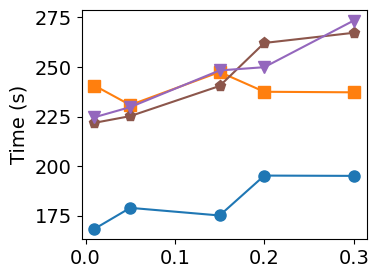

DBLP_agg ADD — IncMiner over BatchMiner: avg 1.31x, max 1.43x


In [12]:
# ADD case: DBLP_agg (IncMiner vs BatchMiner) — inc_vs_batch_v3

dblp_agg_ml = pd.read_csv('inc_vs_batch_v3/experiment_results_dblp_agg.csv')
dblp_agg_add = dblp_agg_ml[dblp_agg_ml['experiment_type'] == 'ADD'].sort_values('inc_ratio')
dblp_ns_add = pd.read_csv('inc_vs_batch_no_sample/experiment_results_dblp_agg.csv')
dblp_ns_add = dblp_ns_add[dblp_ns_add['experiment_type']=='ADD'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
dblp_agg_add = dblp_agg_add.merge(dblp_ns_add, on='inc_ratio', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
dblp_cs_add = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_dblp_agg.csv')
dblp_cs_add = dblp_cs_add[dblp_cs_add['experiment_type']=='ADD'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
dblp_agg_add = dblp_agg_add.merge(dblp_cs_add, on='inc_ratio', how='left')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(dblp_agg_add['inc_ratio'], dblp_agg_add['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(dblp_agg_add['inc_ratio'], dblp_agg_add['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(dblp_agg_add['inc_ratio'], dblp_agg_add['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(
    dblp_agg_add['inc_ratio'],
    dblp_agg_add['inc_cs_time_s'],
    label=r'PIncMiner$_{CS}$',
    **STYLE_MAP[r'PIncMiner$_{CS}$'],
)
# ax.set_xlabel('Increment ratio ($|\\Delta D_+| / |D|$)')
ax.set_ylabel('Time (s)')
# ax.set_title('DBLP_agg (ADD): mining time vs increment ratio')
# ax.set_yscale('log')
fig.savefig('plots/dblp_agg_add.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (dblp_agg_add['inc_time_s'] > 0) & (dblp_agg_add['batch_time_s'].notna()) & (dblp_agg_add['batch_time_s'] > 0)
if valid.any(): s = dblp_agg_add.loc[valid, 'batch_time_s'] / dblp_agg_add.loc[valid, 'inc_time_s']; print(f'DBLP_agg ADD — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


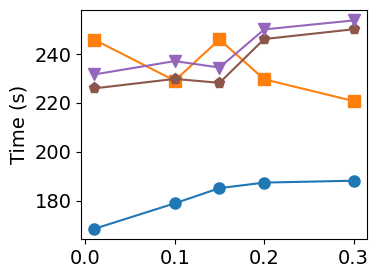

DBLP_agg DELETE — IncMiner over BatchMiner: avg 1.29x, max 1.46x


In [13]:
# DELETE case: DBLP_agg (IncMiner vs BatchMiner) — inc_vs_batch_v3

dblp_agg_delete = dblp_agg_ml[dblp_agg_ml['experiment_type'] == 'DELETE'].sort_values('inc_ratio')
dblp_ns_del = pd.read_csv('inc_vs_batch_no_sample/experiment_results_dblp_agg.csv')
dblp_ns_del = dblp_ns_del[dblp_ns_del['experiment_type']=='DELETE'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
dblp_agg_delete = dblp_agg_delete.merge(dblp_ns_del, on='inc_ratio', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
dblp_cs_del = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_dblp_agg.csv')
dblp_cs_del = dblp_cs_del[dblp_cs_del['experiment_type']=='DELETE'][['inc_ratio','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
dblp_agg_delete = dblp_agg_delete.merge(dblp_cs_del, on='inc_ratio', how='left')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(dblp_agg_delete['inc_ratio'], dblp_agg_delete['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(dblp_agg_delete['inc_ratio'], dblp_agg_delete['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(dblp_agg_delete['inc_ratio'], dblp_agg_delete['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(dblp_agg_delete['inc_ratio'], dblp_agg_delete['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
# ax.set_xlabel('Increment ratio ($|\\Delta D_-| / |D|$)')
ax.set_ylabel('Time (s)')
# ax.set_title('DBLP_agg (DELETE): mining time vs increment ratio')
# ax.set_yscale('log')
fig.savefig('plots/dblp_agg_delete.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (dblp_agg_delete['inc_time_s'] > 0) & (dblp_agg_delete['batch_time_s'].notna()) & (dblp_agg_delete['batch_time_s'] > 0)
if valid.any(): s = dblp_agg_delete.loc[valid, 'batch_time_s'] / dblp_agg_delete.loc[valid, 'inc_time_s']; print(f'DBLP_agg DELETE — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


## Vary Sigma

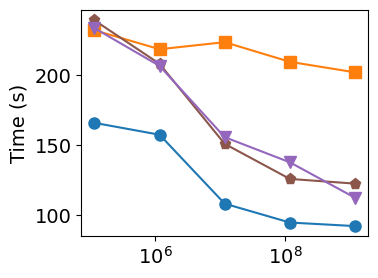

DBLP_agg SUPPORT — IncMiner over BatchMiner: avg 1.85x, max 2.21x


In [14]:
# SUPPORT experiment: DBLP_agg (IncMiner vs BatchMiner) — inc_vs_batch_v3

# Load and filter SUPPORT experiment (varying minimum support threshold)
dblp_support = pd.read_csv('inc_vs_batch_v3/experiment_results_dblp_agg.csv')
dblp_support = dblp_support[dblp_support['experiment_type'] == 'SUPPORT'].sort_values('support')
dblp_ns_sup = pd.read_csv('inc_vs_batch_no_sample/experiment_results_dblp_agg.csv')
dblp_ns_sup = dblp_ns_sup[dblp_ns_sup['experiment_type']=='SUPPORT'][['support','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
dblp_support = dblp_support.merge(dblp_ns_sup, on='support', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
dblp_cs_sup = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_dblp_agg.csv')
dblp_cs_sup = dblp_cs_sup[dblp_cs_sup['experiment_type']=='SUPPORT'][['support','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
dblp_support = dblp_support.merge(dblp_cs_sup, on='support', how='left')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(dblp_support['support'], dblp_support['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(dblp_support['support'], dblp_support['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(dblp_support['support'], dblp_support['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(dblp_support['support'], dblp_support['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
ax.set_ylabel('Time (s)')
# ax.set_title('DBLP_agg (SUPPORT): mining time vs support threshold')
ax.set_xscale('log')
# ax.set_yscale('log')
fig.savefig('plots/dblp_agg_support.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (dblp_support['inc_time_s'] > 0) & (dblp_support['batch_time_s'].notna()) & (dblp_support['batch_time_s'] > 0)
if valid.any(): s = dblp_support.loc[valid, 'batch_time_s'] / dblp_support.loc[valid, 'inc_time_s']; print(f'DBLP_agg SUPPORT — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


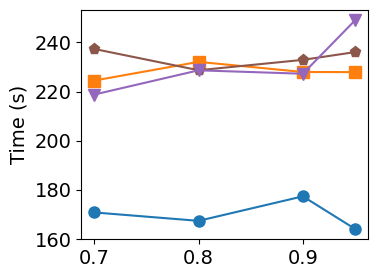

DBLP_agg CONFIDENCE — IncMiner over BatchMiner: avg 1.34x, max 1.39x


In [15]:
# CONFIDENCE experiment: DBLP_agg (IncMiner vs BatchMiner) — inc_vs_batch_v3

# Load and filter CONFIDENCE experiment (varying confidence threshold)
dblp_confidence = pd.read_csv('inc_vs_batch_v3/experiment_results_dblp_agg.csv')
dblp_confidence = dblp_confidence[dblp_confidence['experiment_type'] == 'CONFIDENCE'].sort_values('confidence')
dblp_ns_conf = pd.read_csv('inc_vs_batch_no_sample/experiment_results_dblp_agg.csv')
dblp_ns_conf = dblp_ns_conf[dblp_ns_conf['experiment_type']=='CONFIDENCE'][['confidence','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
dblp_confidence = dblp_confidence.merge(dblp_ns_conf, on='confidence', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
dblp_cs_conf = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_dblp_agg.csv')
dblp_cs_conf = dblp_cs_conf[dblp_cs_conf['experiment_type']=='CONFIDENCE'][['confidence','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
dblp_confidence = dblp_confidence.merge(dblp_cs_conf, on='confidence', how='left')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(dblp_confidence['confidence'], dblp_confidence['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(dblp_confidence['confidence'], dblp_confidence['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(dblp_confidence['confidence'], dblp_confidence['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(dblp_confidence['confidence'], dblp_confidence['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
# ax.set_xlabel('Confidence threshold')
ax.set_ylabel('Time (s)')
# ax.set_title('DBLP_agg (CONFIDENCE): mining time vs confidence threshold')
# ax.set_yscale('log')
fig.savefig('plots/dblp_agg_confidence.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (dblp_confidence['inc_time_s'] > 0) & (dblp_confidence['batch_time_s'].notna()) & (dblp_confidence['batch_time_s'] > 0)
if valid.any(): s = dblp_confidence.loc[valid, 'batch_time_s'] / dblp_confidence.loc[valid, 'inc_time_s']; print(f'DBLP_agg CONFIDENCE — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


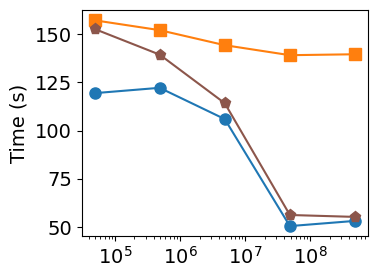

Inspection SUPPORT — IncMiner over BatchMiner: avg 1.86x, max 2.75x


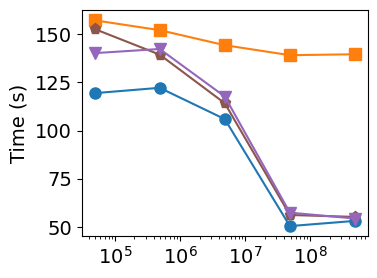

Inspection SUPPORT — IncMiner over BatchMiner: avg 1.86x, max 2.75x


In [16]:
# SUPPORT experiment: inspection_ml (IncMiner vs BatchMiner) — inc_vs_batch_v3

inspection_ml = pd.read_csv('inc_vs_batch_v3/experiment_results_inspection_ml.csv')
inspection_support = inspection_ml[inspection_ml['experiment_type'] == 'SUPPORT'].sort_values('support')
inspection_ns = pd.read_csv('inc_vs_batch_no_sample/experiment_results_inspection_ml.csv')
inspection_ns_sup = inspection_ns[inspection_ns['experiment_type']=='SUPPORT'][['support','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
inspection_support = inspection_support.merge(inspection_ns_sup, on='support', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
inspection_cs_sup = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_inspection_ml.csv')
inspection_cs_sup = inspection_cs_sup[inspection_cs_sup['experiment_type']=='SUPPORT'][['support','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
inspection_support = inspection_support.merge(inspection_cs_sup, on='support', how='left')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(inspection_support['support'], inspection_support['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(inspection_support['support'], inspection_support['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(inspection_support['support'], inspection_support['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(inspection_support['support'], inspection_support['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
# ax.set_xlabel('Support threshold')
ax.set_ylabel('Time (s)')
# ax.set_title('Inspection_ml (SUPPORT): mining time vs support threshold')
ax.set_xscale('log')
fig.savefig('plots/inspection_support.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (inspection_support['inc_time_s'] > 0) & (inspection_support['batch_time_s'].notna()) & (inspection_support['batch_time_s'] > 0)
if valid.any(): s = inspection_support.loc[valid, 'batch_time_s'] / inspection_support.loc[valid, 'inc_time_s']; print(f'Inspection SUPPORT — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


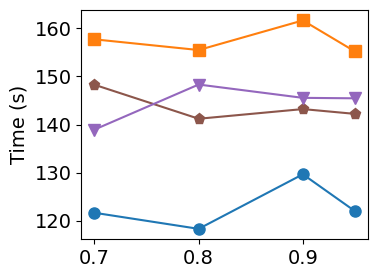

Inspection CONFIDENCE — IncMiner over BatchMiner: avg 1.28x, max 1.31x


In [17]:
# CONFIDENCE experiment: inspection_ml (IncMiner vs BatchMiner) — inc_vs_batch_v3

inspection_confidence = inspection_ml[inspection_ml['experiment_type'] == 'CONFIDENCE'].sort_values('confidence')
inspection_ns = pd.read_csv('inc_vs_batch_no_sample/experiment_results_inspection_ml.csv')
inspection_ns_conf = inspection_ns[inspection_ns['experiment_type']=='CONFIDENCE'][['confidence','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
inspection_confidence = inspection_confidence.merge(inspection_ns_conf, on='confidence', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
inspection_cs_conf = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_inspection_ml.csv')
inspection_cs_conf = inspection_cs_conf[inspection_cs_conf['experiment_type']=='CONFIDENCE'][['confidence','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
inspection_confidence = inspection_confidence.merge(inspection_cs_conf, on='confidence', how='left')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(inspection_confidence['confidence'], inspection_confidence['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(inspection_confidence['confidence'], inspection_confidence['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(inspection_confidence['confidence'], inspection_confidence['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(inspection_confidence['confidence'], inspection_confidence['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
# ax.set_xlabel('Confidence threshold')
ax.set_ylabel('Time (s)')
# ax.set_title('Inspection_ml (CONFIDENCE): mining time vs confidence threshold')
# ax.set_yscale('log')
fig.savefig('plots/inspection_confidence.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (inspection_confidence['inc_time_s'] > 0) & (inspection_confidence['batch_time_s'].notna()) & (inspection_confidence['batch_time_s'] > 0)
if valid.any(): s = inspection_confidence.loc[valid, 'batch_time_s'] / inspection_confidence.loc[valid, 'inc_time_s']; print(f'Inspection CONFIDENCE — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


# Exp2

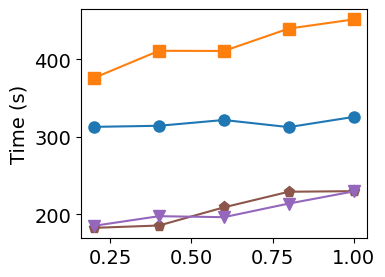

DBLP_agg SCALE — IncMiner over BatchMiner: avg 1.32x, max 1.41x


In [323]:
# SCALE experiment: DBLP_agg (IncMiner vs BatchMiner) — inc_vs_batch_v3

# dblp_scale = pd.read_csv('inc_vs_batch_v3/experiment_results_dblp_agg.csv')
dblp_scale = pd.read_csv('dblp_v3/experiment_results_dblp_agg_v3.csv')
dblp_scale = dblp_scale[dblp_scale['experiment_type'] == 'SCALE'].sort_values('scale')
dblp_ns_scale = pd.read_csv('inc_vs_batch_no_sample/experiment_results_dblp_agg.csv')
dblp_ns_scale = dblp_ns_scale[dblp_ns_scale['experiment_type']=='SCALE'][['scale','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
dblp_scale = dblp_scale.merge(dblp_ns_scale, on='scale', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
dblp_cs_scale = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_dblp_agg.csv')
dblp_cs_scale = dblp_cs_scale[dblp_cs_scale['experiment_type']=='SCALE'][['scale','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
dblp_scale = dblp_scale.merge(dblp_cs_scale, on='scale', how='left')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(dblp_scale['scale'], dblp_scale['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(dblp_scale['scale'], dblp_scale['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(dblp_scale['scale'], dblp_scale['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(dblp_scale['scale'], dblp_scale['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
ax.set_ylabel('Time (s)')
fig.savefig('plots/dblp_agg_scale.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (dblp_scale['inc_time_s'] > 0) & (dblp_scale['batch_time_s'].notna()) & (dblp_scale['batch_time_s'] > 0)
if valid.any(): s = dblp_scale.loc[valid, 'batch_time_s'] / dblp_scale.loc[valid, 'inc_time_s']; print(f'DBLP_agg SCALE — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


In [ ]:
# SCALE experiment: adult_ml (IncMiner vs BatchMiner) — inc_vs_batch_v3

adult_ml = pd.read_csv('inc_vs_batch_v3/experiment_results_adult_ml.csv')
adult_ml_scale = adult_ml[adult_ml['experiment_type'] == 'SCALE'].sort_values('scale')
adult_ns_scale = pd.read_csv('inc_vs_batch_no_sample/experiment_results_adult_ml.csv')
adult_ns_scale = adult_ns_scale[adult_ns_scale['experiment_type']=='SCALE'][['scale','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
adult_ml_scale = adult_ml_scale.merge(adult_ns_scale, on='scale', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
adult_cs_scale = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_adult_ml.csv')
adult_cs_scale = adult_cs_scale[adult_cs_scale['experiment_type']=='SCALE'][['scale','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
adult_ml_scale = adult_ml_scale.merge(adult_cs_scale, on='scale', how='left')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(adult_ml_scale['scale'], adult_ml_scale['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(adult_ml_scale['scale'], adult_ml_scale['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(adult_ml_scale['scale'], adult_ml_scale['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(adult_ml_scale['scale'], adult_ml_scale['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
ax.set_ylabel('Time (s)')
fig.savefig('plots/adult_scale.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (adult_ml_scale['inc_time_s'] > 0) & (adult_ml_scale['batch_time_s'].notna()) & (adult_ml_scale['batch_time_s'] > 0)
if valid.any(): s = adult_ml_scale.loc[valid, 'batch_time_s'] / adult_ml_scale.loc[valid, 'inc_time_s']; print(f'Adult SCALE — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


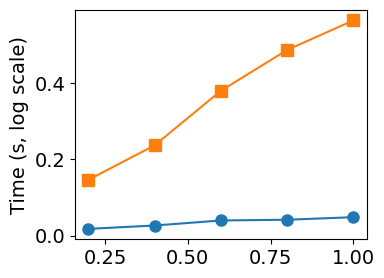

Adult DC SCALE — IncMiner over BatchMiner: avg 10.00x, max 11.68x


In [295]:
# SCALE experiment: Adult (vs_incdc) — IncMiner vs BatchMiner

df_adult_scale = pd.read_csv('vs_incdc/experiment_results_adult.csv')
df_adult_scale = df_adult_scale[df_adult_scale['experiment_type'] == 'SCALE'].sort_values('scale')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(df_adult_scale['scale'], df_adult_scale['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(df_adult_scale['scale'], df_adult_scale['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.set_ylabel('Time (s, log scale)')
fig.savefig('plots/adult_dc_scale.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (df_adult_scale['inc_time_s'] > 0) & (df_adult_scale['batch_time_s'].notna()) & (df_adult_scale['batch_time_s'] > 0)
if valid.any(): s = df_adult_scale.loc[valid, 'batch_time_s'] / df_adult_scale.loc[valid, 'inc_time_s']; print(f'Adult DC SCALE — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


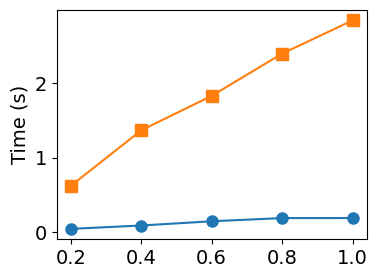

Airports DC SCALE — IncMiner over BatchMiner: avg 13.56x, max 14.91x


In [305]:
# SCALE experiment: Airports (vs_incdc) — IncMiner vs BatchMiner

df_airports_scale = pd.read_csv('vs_incdc/experiment_results_airports.csv')
df_airports_scale = df_airports_scale[df_airports_scale['experiment_type'] == 'SCALE'].sort_values('scale')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(df_airports_scale['scale'], df_airports_scale['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(df_airports_scale['scale'], df_airports_scale['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.set_ylabel('Time (s)')
fig.savefig('plots/airports_dc_scale.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()
valid = (df_airports_scale['inc_time_s'] > 0) & (df_airports_scale['batch_time_s'].notna()) & (df_airports_scale['batch_time_s'] > 0)
if valid.any(): s = df_airports_scale.loc[valid, 'batch_time_s'] / df_airports_scale.loc[valid, 'inc_time_s']; print(f'Airports DC SCALE — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')


DBLP_agg MACHINES: speedup (n=4 → n=20) — IncMiner: 2.92x, BatchMiner: 2.16x
DBLP_agg MACHINES — IncMiner over BatchMiner: avg 1.76x, max 2.02x


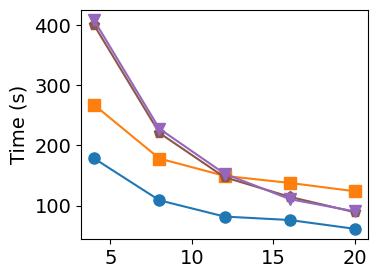

In [53]:
# MACHINES experiment: DBLP_agg (IncMiner vs BatchMiner) 

# dblp_machines = pd.read_csv('inc_vs_batch_v3/experiment_results_dblp_agg.csv')
dblp_machines = pd.read_csv('inc_vs_batch_worker_v2/experiment_results_dblp_agg_v2.csv')

dblp_machines = dblp_machines[dblp_machines['experiment_type'] == 'MACHINES'].sort_values('machines')
dblp_ns_mach = pd.read_csv('inc_vs_batch_no_sample/experiment_results_dblp_agg.csv')
dblp_ns_mach = dblp_ns_mach[dblp_ns_mach['experiment_type']=='MACHINES'][['machines','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
dblp_machines = dblp_machines.merge(dblp_ns_mach, on='machines', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
dblp_cs_mach = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_dblp_agg.csv')
dblp_cs_mach = dblp_cs_mach[dblp_cs_mach['experiment_type']=='MACHINES'][['machines','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
dblp_machines = dblp_machines.merge(dblp_cs_mach, on='machines', how='left')

# Speedup: time at 4 machines / time at 20 machines
t_inc_4 = dblp_machines.loc[dblp_machines['machines'] == 4, 'inc_time_s'].values[0]
t_inc_20 = dblp_machines.loc[dblp_machines['machines'] == 20, 'inc_time_s'].values[0]
t_batch_4 = dblp_machines.loc[dblp_machines['machines'] == 4, 'batch_time_s'].values[0]
t_batch_20 = dblp_machines.loc[dblp_machines['machines'] == 20, 'batch_time_s'].values[0]
speedup_inc = t_inc_4 / t_inc_20
speedup_batch = t_batch_4 / t_batch_20
print(f'DBLP_agg MACHINES: speedup (n=4 → n=20) — IncMiner: {speedup_inc:.2f}x, BatchMiner: {speedup_batch:.2f}x')
valid = (dblp_machines['inc_time_s'] > 0) & (dblp_machines['batch_time_s'].notna()) & (dblp_machines['batch_time_s'] > 0)
if valid.any(): s = dblp_machines.loc[valid, 'batch_time_s'] / dblp_machines.loc[valid, 'inc_time_s']; print(f'DBLP_agg MACHINES — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(dblp_machines['machines'], dblp_machines['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(dblp_machines['machines'], dblp_machines['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(dblp_machines['machines'], dblp_machines['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(dblp_machines['machines'], dblp_machines['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
ax.set_ylabel('Time (s)')
fig.savefig('plots/dblp_agg_machines.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

Ncvoter_ml MACHINES: speedup (n=4 → n=20) — IncMiner: 3.38x, BatchMiner: 3.51x
Ncvoter MACHINES — IncMiner over BatchMiner: avg 3.18x, max 3.68x


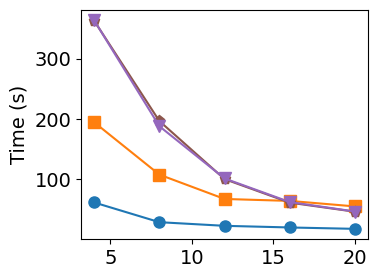

In [30]:
# MACHINES experiment: ncvoter_ml (IncMiner vs BatchMiner) — inc_vs_batch_v3

# ncvoter_machines = pd.read_csv('inc_vs_batch_v3/experiment_results_ncvoter_ml.csv')
ncvoter_machines = pd.read_csv('inc_vs_batch_worker_v2/experiment_results_ncvoter_ml_v2.csv')
ncvoter_machines = ncvoter_machines[ncvoter_machines['experiment_type'] == 'MACHINES'].sort_values('machines')
ncvoter_ns_mach = pd.read_csv('inc_vs_batch_no_sample/experiment_results_ncvoter_ml.csv')
ncvoter_ns_mach = ncvoter_ns_mach[ncvoter_ns_mach['experiment_type']=='MACHINES'][['machines','inc_time_s']].rename(columns={'inc_time_s':'inc_ns_time_s'})
ncvoter_machines = ncvoter_machines.merge(ncvoter_ns_mach, on='machines', how='left')

# IncMinerCS baseline from inc_vs_batch_no_count_sketch
ncvoter_cs_mach = pd.read_csv('inc_vs_batch_no_count_sketch/experiment_results_ncvoter_ml.csv')
ncvoter_cs_mach = ncvoter_cs_mach[ncvoter_cs_mach['experiment_type']=='MACHINES'][['machines','inc_time_s']].rename(columns={'inc_time_s':'inc_cs_time_s'})
ncvoter_machines = ncvoter_machines.merge(ncvoter_cs_mach, on='machines', how='left')

# Speedup: time at 4 machines / time at 20 machines
t_inc_4 = ncvoter_machines.loc[ncvoter_machines['machines'] == 4, 'inc_time_s'].values[0]
t_inc_20 = ncvoter_machines.loc[ncvoter_machines['machines'] == 20, 'inc_time_s'].values[0]
t_batch_4 = ncvoter_machines.loc[ncvoter_machines['machines'] == 4, 'batch_time_s'].values[0]
t_batch_20 = ncvoter_machines.loc[ncvoter_machines['machines'] == 20, 'batch_time_s'].values[0]
speedup_inc = t_inc_4 / t_inc_20
speedup_batch = t_batch_4 / t_batch_20
print(f'Ncvoter_ml MACHINES: speedup (n=4 → n=20) — IncMiner: {speedup_inc:.2f}x, BatchMiner: {speedup_batch:.2f}x')
valid = (ncvoter_machines['inc_time_s'] > 0) & (ncvoter_machines['batch_time_s'].notna()) & (ncvoter_machines['batch_time_s'] > 0)
if valid.any(): s = ncvoter_machines.loc[valid, 'batch_time_s'] / ncvoter_machines.loc[valid, 'inc_time_s']; print(f'Ncvoter MACHINES — IncMiner over BatchMiner: avg {s.mean():.2f}x, max {s.max():.2f}x')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ncvoter_machines['machines'], ncvoter_machines['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(ncvoter_machines['machines'], ncvoter_machines['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(ncvoter_machines['machines'], ncvoter_machines['inc_ns_time_s'], label=r'PIncMiner$_{Aux}$', **STYLE_MAP[r'PIncMiner$_{Aux}$'])
ax.plot(ncvoter_machines['machines'], ncvoter_machines['inc_cs_time_s'], label=r'PIncMiner$_{CS}$', **STYLE_MAP[r'PIncMiner$_{CS}$'])
ax.set_ylabel('Time (s)')
fig.savefig('plots/ncvoter_machines.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

# Exp-3

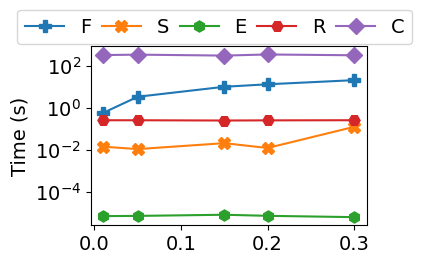

In [251]:
# Performance breakdown (ADD only, x = inc_ratio): stack plot — shared defs


BREAKDOWN_COLS = ['inc_filtering_time_s', 'inc_revisit_time_s', 'inc_expansion_time_s', 'inc_model_retrain_time_s', 'inc_decision_tree_time_s']
# LABELS = ['Filtering', 'Sample', 'Expansion', 'Retrain', 'Constant']
LABELS = ['F', 'S', 'E', 'R', 'C']
BREAKDOWN_MARKERS = ['P', 'X', 'h', 'H', 'D']  # plus, X, hexagon, hexagon2, thin diamond (distinct from STYLE_MAP)

# DBLP_agg — inc_vs_batch_v3
df = pd.read_csv('inc_vs_batch_v3/experiment_results_dblp_agg.csv')
df = df[df['experiment_type'] == 'ADD'].sort_values('inc_ratio')
x = df['inc_ratio']
fig, ax = plt.subplots(figsize=(4, 3))
for i, col in enumerate(BREAKDOWN_COLS):
    ax.plot(x, df[col], label=LABELS[i], marker=BREAKDOWN_MARKERS[i], markersize=MARKER_SIZE)
ax.set_ylabel('Time (s)')
ax.set_yscale('log')
ax.legend(loc='upper center', bbox_to_anchor=(-0.3, 1.08, 1.5, 0.18), ncol=5, mode='expand', frameon=True)
fig.savefig('plots/dblp_add_breakdown.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()


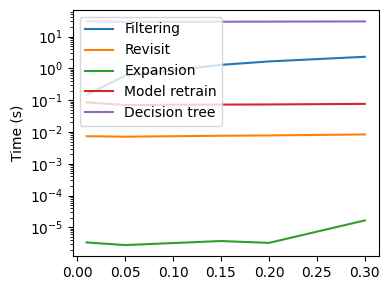

In [168]:
# Performance breakdown: hospital_ml (ADD, stack plot)

df = pd.read_csv('inc_vs_batch_v3/experiment_results_hospital_ml.csv')
df = df[df['experiment_type'] == 'ADD'].sort_values('inc_ratio')
x = df['inc_ratio']
fig, ax = plt.subplots(figsize=(4, 3))
for i, col in enumerate(BREAKDOWN_COLS):
    ax.plot(x, df[col], label=LABELS[i], marker=BREAKDOWN_MARKERS[i], markersize=MARKER_SIZE)
ax.set_ylabel('Time (s)')
ax.set_yscale('log')
ax.legend(loc='upper center', bbox_to_anchor=(-0.04, 1.08, 1.08, 0.18), ncol=3, mode='expand', frameon=True)
plt.tight_layout()
plt.show()

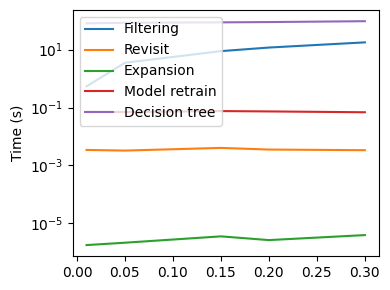

In [169]:
# Performance breakdown: ncvoter_ml (ADD, stack plot)

df = pd.read_csv('inc_vs_batch_v3/experiment_results_ncvoter_ml.csv')
df = df[df['experiment_type'] == 'ADD'].sort_values('inc_ratio')
x = df['inc_ratio']
fig, ax = plt.subplots(figsize=(4, 3))
for i, col in enumerate(BREAKDOWN_COLS):
    ax.plot(x, df[col], label=LABELS[i], marker=BREAKDOWN_MARKERS[i], markersize=MARKER_SIZE)
ax.set_ylabel('Time (s)')
ax.set_yscale('log')
ax.legend(loc='upper center', bbox_to_anchor=(-0.04, 1.08, 1.08, 0.18), ncol=3, mode='expand', frameon=True)
plt.tight_layout()
plt.show()

## Vary w

counter_sketch_w that minimizes time: 2147483648 (inc_time_s=3.20s, memory=327751.46 MB)


/var/folders/mv/j_58gf917nd0c2nczfjyc3900000gn/T/ipykernel_16254/3900725789.py:36: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(m.min() - 0.5 * (m.max() - m.min() or 1), m.max() + 0.5 * (m.max() - m.min() or 1))


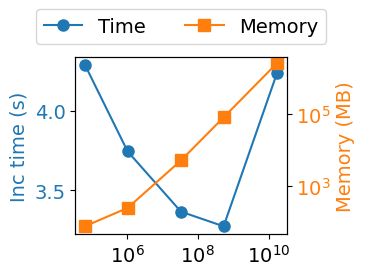

In [52]:
# Vary W (counter_sketch_w): Adult dataset — inc_time_s (left) and memory (right)

import numpy as np

# df = pd.read_csv('inc_vs_batch_v3/experiment_results_adult_ml.csv')
df = pd.read_csv('inc_vs_batch_extend_cs_w/experiment_results_adult_ml_v3.csv')
df = df[df['experiment_type'] == 'COUNT-SKETCH-W'].sort_values('counter_sketch_w').head(19)
# x that minimizes inc_time_s (over first 20 points)
row_min = df.loc[df['inc_time_s'].idxmin()]
x_min_time, t_min, mem_min = row_min['counter_sketch_w'], row_min['inc_time_s'], row_min['inc_memory_mb']
print(f'counter_sketch_w that minimizes time: {x_min_time} (inc_time_s={t_min:.2f}s, memory={mem_min:.2f} MB)')
# Sample 5 evenly spaced points for plotting
if len(df) > 5:
    idx = np.linspace(0, len(df) - 1, 5, dtype=int)
    df = df.iloc[idx].reset_index(drop=True)
x = df['counter_sketch_w']

fig, ax1 = plt.subplots(figsize=(4, 3))
ax1.plot(x, df['inc_time_s'], color='C0', label='Time', marker='o', markersize=MARKER_SIZE)
ax1.set_ylabel('Inc time (s)', color='C0')

ax1.tick_params(axis='y', labelcolor='C0')

ax2 = ax1.twinx()
ax2.plot(x, df['inc_memory_mb'], color='C1', label='Memory', marker='s', markersize=MARKER_SIZE)
ax2.set_ylabel('Memory (MB)', color='C1')

ax2.tick_params(axis='y', labelcolor='C1')

ax1.set_xscale('log')
ax2.set_yscale('log')

# ax1.set_ylim(3, 5)
t = df['inc_time_s']
m = df['inc_memory_mb']
ax2.set_ylim(m.min() - 0.5 * (m.max() - m.min() or 1), m.max() + 0.5 * (m.max() - m.min() or 1))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

fig.savefig('plots/adult_w.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Vary h

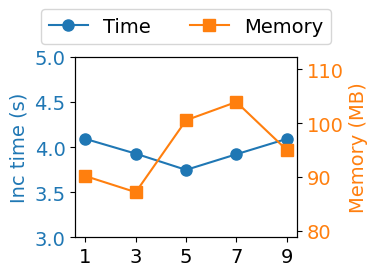

In [269]:
# Vary H (counter_sketch_h): Adult dataset — inc_time_s (left) and memory (right)

df = pd.read_csv('inc_vs_batch_v3/experiment_results_adult_ml.csv')
df = df[df['experiment_type'] == 'COUNT-SKETCH-H'].sort_values('counter_sketch_h')
x = df['counter_sketch_h']

fig, ax1 = plt.subplots(figsize=(4, 3))
ax1.plot(x, df['inc_time_s'], color='C0', label='Time', marker='o', markersize=MARKER_SIZE)
ax1.set_ylabel('Inc time (s)', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

ax2 = ax1.twinx()
ax2.plot(x, df['inc_memory_mb'], color='C1', label='Memory', marker='s', markersize=MARKER_SIZE)
ax2.set_ylabel('Memory (MB)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

ax1.set_xticks(x)
ax1.set_xticklabels(x)

ax1.set_ylim(3, 5)
t = df['inc_time_s']
m = df['inc_memory_mb']
ax2.set_ylim(m.min() - 0.5 * (m.max() - m.min() or 1), m.max() + 0.5 * (m.max() - m.min() or 1))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

fig.savefig('plots/adult_h.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

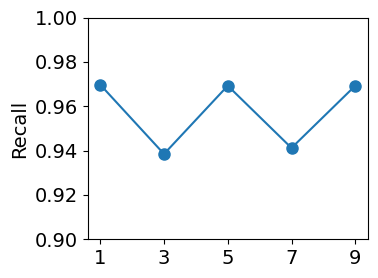

In [268]:
# Recall vs varying h (counter_sketch_h): Adult dataset

df = pd.read_csv('inc_vs_batch_v3/experiment_results_adult_ml.csv')
df = df[df['experiment_type'] == 'COUNT-SKETCH-H'].sort_values('counter_sketch_h')

fig, ax = plt.subplots(figsize=(4, 3))
x = df['counter_sketch_h']
ax.plot(x, df['inc_recall'], marker='o', markersize=MARKER_SIZE)
ax.set_xticks(x)
ax.set_xticklabels(x)
ax.set_ylabel('Recall')
ax.set_ylim(0.9, 1)
from matplotlib.ticker import FormatStrFormatter
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

fig.savefig('plots/adult_recall.pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()

,counter_sketch_h,counter_sketch_failure_probability,inc_recall,expected
11,1,2.718282,0.969697,0.972817
12,3,1.395612,0.938462,0.986044
13,5,1.221403,0.969231,0.987786
14,7,1.153565,0.941176,0.988464
15,9,1.117519,0.969231,0.988825


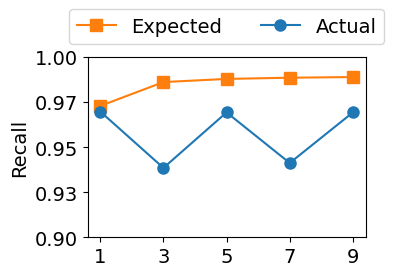

In [277]:
# Expected (1 - failure prob) vs actual recall, varying h: same source as above
df = pd.read_csv('inc_vs_batch_v3/experiment_results_adult_ml.csv')
df = df[df['experiment_type'] == 'COUNT-SKETCH-H'].sort_values('counter_sketch_h')
x = df['counter_sketch_h']
expected = 1 - df['counter_sketch_failure_probability'] / 100

# Raw datapoints
display(df[['counter_sketch_h', 'counter_sketch_failure_probability', 'inc_recall']].assign(expected=expected))

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, expected, marker='s', markersize=MARKER_SIZE, label='Expected', color='C1')
ax.plot(x, df['inc_recall'], marker='o', markersize=MARKER_SIZE, label='Actual', color='C0')
ax.set_xticks(x)
ax.set_xticklabels(x)
ax.set_ylabel('Recall')
ax.set_ylim(0.9, 1)
from matplotlib.ticker import FormatStrFormatter
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
fig.savefig('plots/adult_recall.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

**Why is the failure probability about 1%, and how does it depend on $h$?**

In Count-Sketch, the **height $h$** is the number of independent sketch rows (hash functions). The analysis shows that the probability the estimate exceeds the error bound is **$\delta \approx 2^{-h}$** (or similar in your implementation). So each extra row roughly **halves** the failure probability.

- To get failure probability **about 1%** ($\delta \approx 0.01$), we need $2^{-h} \leq 0.01$, i.e. $h \geq \log_2(100) \approx 6.6$. So **$h \geq 7$** yields $\delta \leq 2^{-7} \approx 0.78\%$.
- In other words: the **choice of $h$** directly sets the failure probability. Larger $h$ → smaller $\delta$; targeting ~1% corresponds to choosing $h$ in the range of about 7 (or as in the plot below, where the reported failure probability decreases as $h$ increases).

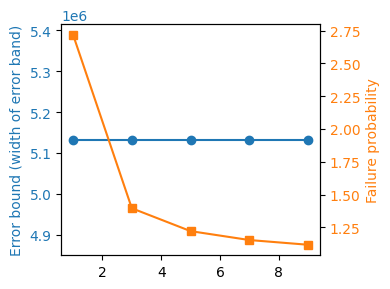

In [173]:
# Count-Sketch: parameters that decide error band width and error probability (vary h)

# Error band width: determined by width w (and stream norm). Larger w → smaller error bound.
# Error (failure) probability: determined by height h. Larger h → smaller failure probability (e.g. ~ 2^{-h}).
# In the vary-h experiment, w is fixed so error_bound is constant; failure_probability decreases with h.

df = pd.read_csv('inc_vs_batch_v3/experiment_results_adult_ml.csv')
df = df[df['experiment_type'] == 'COUNT-SKETCH-H'].sort_values('counter_sketch_h')
x = df['counter_sketch_h']

fig, ax1 = plt.subplots(figsize=(4, 3))
ax1.plot(x, df['counter_sketch_error_bound'], color='C0', marker='o', markersize=MARKER_SIZE, label='Error bound')
ax1.set_ylabel('Error bound (width of error band)', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

ax2 = ax1.twinx()
ax2.plot(x, df['counter_sketch_failure_probability'], color='C1', marker='s', markersize=MARKER_SIZE, label='Failure prob.')
ax2.set_ylabel('Failure probability', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

plt.tight_layout()
plt.show()